# Informe Técnico — Ciclo 1 de Entrenamiento

**Proyecto:** TFM — Detección de objetos para asistencia visual en dispositivos embebidos (TinyML)  
**Pipeline:** Vertex AI (Google Cloud) — GPU T4  
**Fecha:** 11 de febrero de 2026  
**Autor:** Ingeniero de Modelos — Ciclo 1

---

## Objetivo

Documentar y comparar de forma completa los **7 modelos** de detección de objetos entrenados durante el Ciclo 1 con el pipeline automatizado de Vertex AI, evaluar su comportamiento tras cuantización INT8, seleccionar los mejores candidatos de las familias MobileNet y YOLO para despliegue en **ESP32-S3**, y especificar los requerimientos de software del firmware embebido.

### Dataset

| Propiedad | Valor |
|---|---|
| **Clases** | `dog`, `door`, `obstacle`, `person`, `stair` (5 clases) |
| **Resolución de entrada** | 224 × 224 px |
| **Formato** | TFRecord (MobileNet) / YOLO (YOLO11n, YOLO26n) |
| **Splits** | Train / Validation / Test |
| **Origen** | Dataset Maestro Unificado + Augmentation (ver `01_ING_DATOS`) |

### Modelos entrenados

| # | Modelo | Familia |
|---|---|---|
| 1 | MBNTv3S_ssdlite_v1 | MobileNetV3-Small + SSD-Lite |
| 2 | MBNTv3S_ssdlite_v2 | MobileNetV3-Small + SSD-Lite |
| 3 | MBNTv3S_ssdlite_v3 | MobileNetV3-Small + SSD-Lite |
| 4 | MBNTv2_ssdlite_v1 | MobileNetV2 + SSD-Lite |
| 5 | MBNTv2_ssdlite_v2 | MobileNetV2 + SSD-Lite |
| 6 | yolo11n_v1 | YOLO11 Nano |
| 7 | yolo26n_v1 | YOLO26 Nano |

In [1]:
# ─── Importaciones y carga de datos ────────────────────────────────────────
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ─── Rutas base ───────────────────────────────────────────────────────────
BASE = Path("../outputs")

MODELS = {
    # MobileNet family  (v3S_v1 usa carpeta corrected/)
    "MBNTv3S_v1": BASE / "MBNTv3S_ssdlite_v1" / "corrected",
    "MBNTv3S_v2": BASE / "MBNTv3S_ssdlite_v2",
    "MBNTv3S_v3": BASE / "MBNTv3S_ssdlite_v3",
    "MBNTv2_v1":  BASE / "MBNTv2_ssdlite_v1",
    "MBNTv2_v2":  BASE / "MBNTv2_ssdlite_v2",
    # YOLO family
    "YOLO11n_v1": BASE / "yolo11n_v1",
    "YOLO26n_v1": BASE / "yolo26n_v1",
}

# ─── Funciones auxiliares ─────────────────────────────────────────────────
def load_json(path):
    with open(path) as f:
        return json.load(f)

# ─── Cargar experiment.json (contiene config + resultados agregados) ──────
experiments = {k: load_json(v / "experiment.json") for k, v in MODELS.items()}

# ─── Cargar test_evaluation.json (métricas framework en test split) ───────
test_evals = {k: load_json(v / "test_evaluation.json") for k, v in MODELS.items()}

# ─── Cargar export_result.json (info TFLite) ─────────────────────────────
# v3S_v1 corrected/ no tiene export_result → usar el de la raíz
export_results = {}
for k, v in MODELS.items():
    ep = v / "export_result.json"
    if not ep.exists():
        ep = v.parent / "export_result.json"  # fallback a raíz (v3S_v1)
    export_results[k] = load_json(ep)

# ─── Cargar tflite_test_evaluation.json (donde exista) ───────────────────
tflite_evals = {}
for k, v in MODELS.items():
    tp = v / "tflite_test_evaluation.json"
    if tp.exists():
        tflite_evals[k] = load_json(tp)

# ─── Cargar comparison_result.json (solo MobileNet) ──────────────────────
comparisons = {}
for k, v in MODELS.items():
    cp = v / "comparison_result.json"
    if not cp.exists():
        cp = v.parent / "comparison_result.json"
    if cp.exists():
        comparisons[k] = load_json(cp)

CLASS_NAMES = ["dog", "door", "obstacle", "person", "stair"]
MOBILENET_MODELS = [m for m in MODELS if m.startswith("MBNT")]
YOLO_MODELS = [m for m in MODELS if m.startswith("YOLO")]
ALL_MODELS = list(MODELS.keys())

print(f"✓ Cargados {len(experiments)} experimentos")
print(f"  ├─ MobileNet: {MOBILENET_MODELS}")
print(f"  ├─ YOLO:      {YOLO_MODELS}")
print(f"  ├─ TFLite evaluations: {list(tflite_evals.keys())}")
print(f"  └─ Comparisons FW↔TFLite: {list(comparisons.keys())}")

✓ Cargados 7 experimentos
  ├─ MobileNet: ['MBNTv3S_v1', 'MBNTv3S_v2', 'MBNTv3S_v3', 'MBNTv2_v1', 'MBNTv2_v2']
  ├─ YOLO:      ['YOLO11n_v1', 'YOLO26n_v1']
  ├─ TFLite evaluations: ['MBNTv3S_v1', 'YOLO11n_v1', 'YOLO26n_v1']
  └─ Comparisons FW↔TFLite: ['MBNTv3S_v1', 'MBNTv3S_v2', 'MBNTv3S_v3', 'MBNTv2_v1', 'MBNTv2_v2']


---

# 1. Inventario de modelos y arquitecturas

## 1.1 Resumen de los 7 modelos

| # | Modelo | Familia | Backbone | Alpha | Cabezal | Ciclo | Cambio clave |
|---|---|---|---|---|---|---|---|
| 1 | MBNTv3S_ssdlite_v1 | MobileNetV3-Small | V3-Small (minimalistic) | 1.0 | SSD-Lite (sigmoid) | C1 | Baseline |
| 2 | MBNTv3S_ssdlite_v2 | MobileNetV3-Small | V3-Small (minimalistic) | 1.0 | SSD-Lite (sigmoid) | C2 | AdamW, cosine LR, warmup, heavy aug, label smoothing |
| 3 | MBNTv3S_ssdlite_v3 | MobileNetV3-Small | V3-Small (minimalistic) | 1.0 | SSD-Lite (**offset regression**) | C3 | Regresión lineal de offsets Δcx,Δcy,Δw,Δh |
| 4 | MBNTv2_ssdlite_v1 | MobileNetV2 | V2 | 0.5 | SSD-Lite (sigmoid) | C2 | Hereda mejoras de V3S_v2 + backbone V2 α=0.5 |
| 5 | MBNTv2_ssdlite_v2 | MobileNetV2 | V2 | 0.5 | SSD-Lite (**offset regression**) | C3 | + Regresión lineal de offsets |
| 6 | yolo11n_v1 | YOLO11 Nano | YOLO11n (2.6M params) | — | End-to-end (6.5 GFLOPs) | C1 | Ultralytics, pretrained COCO |
| 7 | yolo26n_v1 | YOLO26 Nano | YOLO26n (2.4M params) | — | End-to-end + NMS integrado (5.4 GFLOPs) | C1 | Ultralytics, pretrained COCO |

> **Nota:** MBNTv3S_ssdlite_v1 contenía un bug en la evaluación original (ground truths inflados a 195.412 vs 4.056 reales). Los datos aquí corresponden a la **re-evaluación corregida** (`corrected/`).

## 1.2 Hiperparámetros detallados

### Familia MobileNet (SSD-Lite)

| Parámetro | V3S_v1 | V3S_v2 | V3S_v3 | V2_v1 | V2_v2 |
|---|---|---|---|---|---|
| **Fase 1 — epochs** | 30 | 50 | 50 | 50 | 50 |
| **Fase 1 — LR** | 0.001 | 0.003 | 0.003 | 0.003 | 0.003 |
| **Fase 2 — epochs** | 50 | 250 | 250 | 250 | 250 |
| **Fase 2 — LR** | 5×10⁻⁵ | 1×10⁻⁴ | 1×10⁻⁴ | 1×10⁻⁴ | 1×10⁻⁴ |
| **Capas descongeladas** | 40 | 60 | 60 | 60 | 60 |
| **Batch size** | 32 | 64 | 64 | 64 | 64 |
| **Early stopping (patience)** | 15 | 35 | 35 | 35 | 35 |
| **Optimizer** | Adam | AdamW | AdamW | AdamW | AdamW |
| **Weight decay** | — | 5×10⁻⁴ | 5×10⁻⁴ | 5×10⁻⁴ | 5×10⁻⁴ |
| **LR scheduler** | ReduceOnPlateau | Cosine anneal | Cosine anneal | Cosine anneal | Cosine anneal |
| **LR warmup (epochs)** | 0 | 10 | 10 | 10 | 10 |
| **Label smoothing** | 0 | 0.1 | 0.1 | 0.1 | 0.1 |
| **Augmentation** | medium | heavy | heavy | heavy | heavy |
| **Cls loss weight** | 1.0 | 2.0 | 2.0 | 2.0 | 2.0 |
| **Focal loss (α, γ)** | 0.25, 2.0 | 0.25, 2.0 | 0.25, 2.0 | 0.25, 2.0 | 0.25, 2.0 |
| **Backbone alpha** | 1.0 | 1.0 | 1.0 | **0.5** | **0.5** |
| **Offset regression** | ❌ (sigmoid) | ❌ (sigmoid) | ✅ (lineal) | ❌ (sigmoid) | ✅ (lineal) |
| **Feature channels** | 128 | 128 | 128 | 128 | 128 |
| **Dropout** | 0.2 | 0.2 | 0.2 | 0.2 | 0.2 |
| **Anchor sizes** | 6 (0.1–0.88) | 7 (0.05–0.9) | 7 (0.05–0.9) | 7 (0.05–0.9) | 7 (0.05–0.9) |
| **Anchor ratios** | [1, 2, 0.5, 3, 0.33] | [1, 2, 0.5, 3, 0.33] | [1, 2, 0.5, 3, 0.33] | [1, 2, 0.5, 3, 0.33] | [1, 2, 0.5, 3, 0.33] |

### Familia YOLO (Ultralytics)

| Parámetro | YOLO11n_v1 | YOLO26n_v1 |
|---|---|---|
| **Epochs** | 30 | 30 |
| **Patience (early stopping)** | 30 | 30 |
| **Batch size** | 32 | 32 |
| **Optimizer** | auto (SGD) | auto (SGD) |
| **LR₀ / LRf** | 0.01 / 0.01 | 0.01 / 0.01 |
| **Cosine LR** | Sí | Sí |
| **Momentum** | 0.937 | 0.937 |
| **Weight decay** | 5×10⁻⁴ | 5×10⁻⁴ |
| **Warmup (epochs)** | 3.0 | 3.0 |
| **Mosaic / Mixup** | 1.0 / 0.1 | 1.0 / 0.1 |
| **HSV (h/s/v)** | 0.015 / 0.7 / 0.4 | 0.015 / 0.7 / 0.4 |
| **Box / Cls / DFL loss weight** | 7.5 / 0.5 / 1.5 | 7.5 / 0.5 / 1.5 |
| **AMP (mixed precision)** | Sí | Sí |
| **Pretrained** | ImageNet → COCO | ImageNet → COCO |

## 1.3 Evoluciones arquitectónicas entre ciclos

El pipeline de entrenamiento pasó por **tres iteraciones de diseño**:

### Ciclo 1 — Baseline (V3S_v1)
- Backbone MobileNetV3-Small con transfer learning de ImageNet.
- Cabezal SSD-Lite custom con **salida sigmoid** en el branch de bounding boxes: las predicciones bbox se limitan a [0, 1] interpretadas como coordenadas absolutas normalizadas.
- Entrenamiento en dos fases: congelar backbone (30 epochs) → descongelar parcialmente (50 epochs).
- Optimizer Adam estándar, ReduceOnPlateau, augmentation media.
- **Resultado:** mAP@50 = 0.326 (corregido). Modelo funcional pero con precisión limitada.

### Ciclo 2 — Mejoras de entrenamiento (V3S_v2, V2_v1, YOLO11n, YOLO26n)
- **Cambios de entrenamiento:** AdamW con weight decay, cosine annealing con warmup de 10 epochs, label smoothing 0.1, augmentation pesada, peso de loss de clasificación × 2.
- **Nuevo backbone:** Se introduce MobileNetV2 (α=0.5) como alternativa más ligera y robusta a cuantización.
- **YOLO:** Se entrenan YOLO11n y YOLO26n con Ultralytics API, pretrained de COCO.
- **Resultado:** V3S_v2 mejora a mAP@50 = 0.443 (+36% relativo). Los YOLO dominan con ~0.80.

### Ciclo 3 — Offset regression (V3S_v3, V2_v2)
- **Cambio arquitectónico fundamental:** Se reemplaza la activación sigmoid del branch bbox por una **salida lineal con regresión de offsets** (Δcx, Δcy, Δw, Δh) relativos a los anchors, con varianzas (0.1, 0.2).
- Se identificó que la sigmoid era una **limitación arquitectónica** que restringía la capacidad de localización del modelo.
- **Resultado paradójico:** Los modelos con offset regression (V3S_v3, V2_v2) muestran **mayor precisión** pero **no mejoran mAP@50** respecto a V3S_v2 (de hecho, bajan ligeramente). Hipótesis: el cambio de landscape de la loss requiere un ajuste fino de hiperparámetros (LR, warmup, patience) que no se realizó en este ciclo.

---

# 2. Métricas de entrenamiento (modelo framework)

## 2.1 Resumen de entrenamiento

In [2]:
# ─── 2.1  Tabla de entrenamiento ───────────────────────────────────────────
rows = []
for m in ALL_MODELS:
    r = experiments[m]["results"]
    rows.append({
        "Modelo": m,
        "Familia": "YOLO" if m.startswith("YOLO") else "MobileNet",
        "Epochs totales": r["total_epochs_run"],
        "Mejor epoch": r["best_epoch"],
        "Tiempo (min)": round(r["training_time_min"], 1),
        "Train loss (final)": round(r["final_train_loss"], 4),
        "Val loss (mejor)": round(r["best_val_loss"], 4),
    })

df_train = pd.DataFrame(rows).set_index("Modelo")
display(Markdown("### Resumen de entrenamiento"))
display(df_train.style
    .format(precision=4)
    .background_gradient(subset=["Tiempo (min)"], cmap="YlOrRd")
    .background_gradient(subset=["Val loss (mejor)"], cmap="YlOrRd")
    .set_caption("Tabla 2.1 — Resumen de entrenamiento de los 7 modelos")
)

### Resumen de entrenamiento

,Familia,Epochs totales,Mejor epoch,Tiempo (min),Train loss (final),Val loss (mejor)
Modelo,,,,,,
MBNTv3S_v1,MobileNet,80,73,44.9000,0.0349,0.0424
MBNTv3S_v2,MobileNet,241,205,123.1000,0.0489,0.0803
MBNTv3S_v3,MobileNet,300,291,248.2000,0.5569,1.0087
MBNTv2_v1,MobileNet,126,90,73.9000,0.0476,0.0830
MBNTv2_v2,MobileNet,249,213,211.0000,0.4577,1.0181
YOLO11n_v1,YOLO,30,29,20.4000,2.9608,3.0788
YOLO26n_v1,YOLO,30,29,28.1000,2.0186,1.9951


## 2.2 mAP@50 en test split (modelo framework)

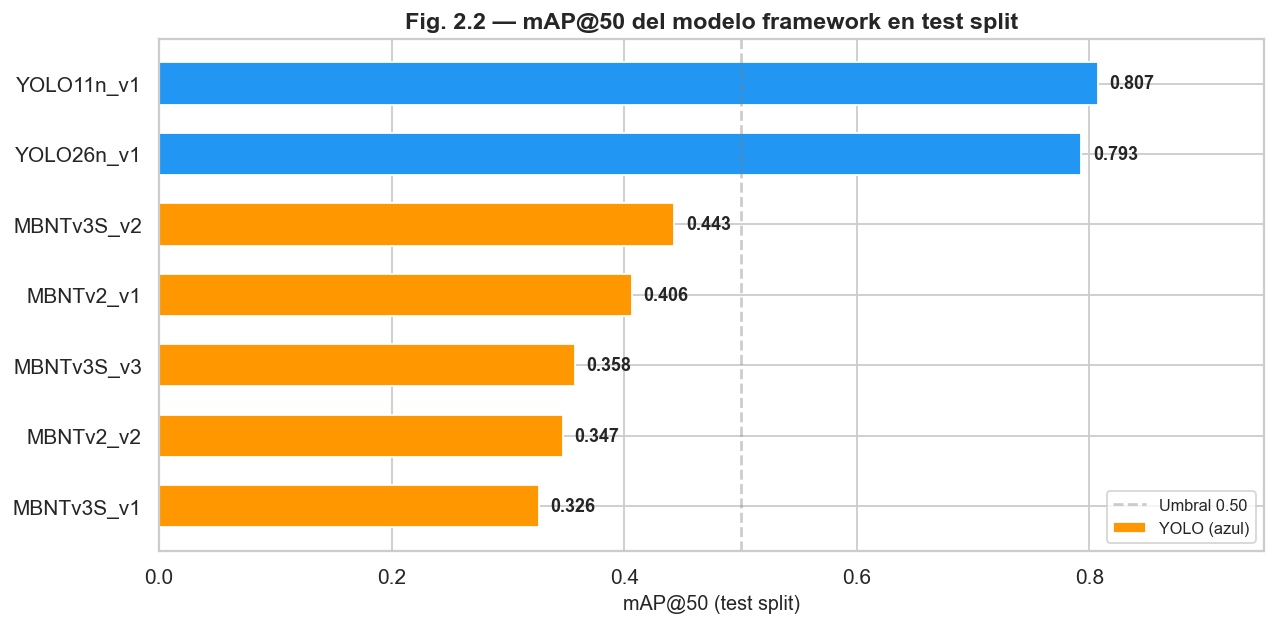

In [3]:
# ─── 2.2  Gráfico de barras — mAP@50 framework (test) ─────────────────────
fw_map = {m: test_evals[m]["mAP50"] for m in ALL_MODELS}
df_map = pd.Series(fw_map, name="mAP@50").sort_values(ascending=True)

colors = ["#2196F3" if m.startswith("YOLO") else "#FF9800" for m in df_map.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_map.index, df_map.values, color=colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, df_map.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("mAP@50 (test split)")
ax.set_title("Fig. 2.2 — mAP@50 del modelo framework en test split", fontsize=13, fontweight="bold")
ax.set_xlim(0, 0.95)
ax.axvline(0.5, color="gray", ls="--", alpha=0.4, label="umbral 0.5")
ax.legend(["Umbral 0.50", "YOLO (azul)", "MobileNet (naranja)"], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 2.3 AP@50 por clase (modelo framework — test split)

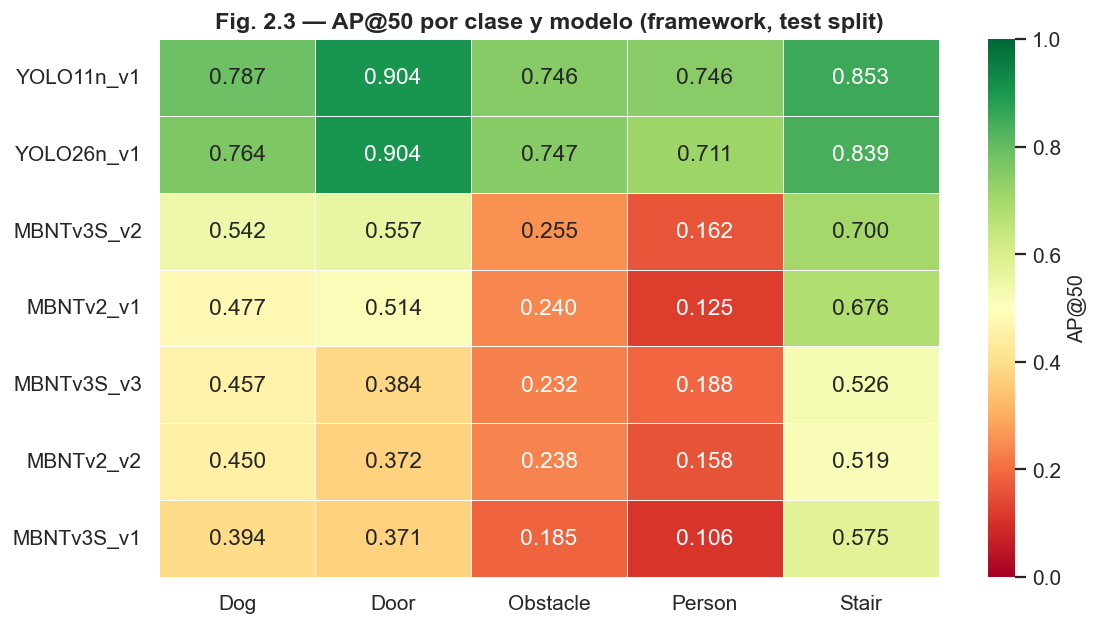

,Dog,Door,Obstacle,Person,Stair,mAP@50
YOLO11n_v1,0.787500,0.904300,0.746300,0.745600,0.853400,0.807400
YOLO26n_v1,0.764300,0.904500,0.746500,0.711300,0.839200,0.793200
MBNTv3S_v2,0.541500,0.557500,0.254500,0.162100,0.699700,0.443100
MBNTv2_v1,0.477400,0.514000,0.239600,0.125000,0.676100,0.406400
MBNTv3S_v3,0.457500,0.383800,0.232400,0.188300,0.525600,0.357500
MBNTv2_v2,0.449800,0.372100,0.237800,0.157900,0.519100,0.347300
MBNTv3S_v1,0.394300,0.371100,0.185200,0.105600,0.575100,0.326300


In [4]:
# ─── 2.3  Heatmap AP@50 por clase (framework) ─────────────────────────────
# Ordenar modelos por mAP@50 descendente
order = sorted(ALL_MODELS, key=lambda m: test_evals[m]["mAP50"], reverse=True)
ap_data = {m: test_evals[m]["per_class_ap50"] for m in order}
df_ap = pd.DataFrame(ap_data, index=CLASS_NAMES).T
df_ap.columns = [c.capitalize() for c in df_ap.columns]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(df_ap, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "AP@50"})
ax.set_title("Fig. 2.3 — AP@50 por clase y modelo (framework, test split)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Tabla numérica complementaria
df_ap["mAP@50"] = df_ap.mean(axis=1)
display(df_ap.round(4).style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption("Tabla 2.3 — AP@50 por clase y mAP@50 promedio (framework)")
)

## 2.4 Análisis interpretativo

### ¿Por qué los YOLO dominan?

| Factor | YOLO | MobileNet SSD-Lite |
|---|---|---|
| **Pretraining** | ImageNet → COCO (detección) | ImageNet (clasificación) |
| **Arquitectura** | End-to-end con feature pyramid | Backbone + cabezal SSD-Lite custom |
| **Optimización** | Ultralytics (madurez de años) | Pipeline custom en desarrollo |
| **Loss** | CIoU + DFL + BCE | Focal + Smooth-L1 |
| **Data augmentation** | Mosaic + Mixup (estado del arte) | Albumentations (heavy) |

Los modelos YOLO parten de una ventaja significativa: su pretraining incluye detección en COCO (80 clases), mientras que los MobileNet solo transfieren features de clasificación de ImageNet. Además, Ultralytics ha optimizado durante años cada componente del pipeline.

### Clases difíciles vs. fáciles

- **`person` y `obstacle`** son las clases más difíciles para todos los modelos — AP@50 < 0.25 en MobileNet y < 0.75 en YOLO. Posibles causas: gran variabilidad morfológica, solapamiento con otras clases, menor representación en el dataset.
- **`stair` y `door`** son las más fáciles — geometrías bien definidas, texturas consistentes.

### ¿Por qué offset regression no mejoró el mAP?

Los modelos V3S_v3 y V2_v2 (offset regression) muestran **mayor precisión** (menos falsos positivos) pero **menor recall** que sus predecesores con sigmoid. Esto sugiere que:

1. La regresión de offsets produce detecciones más precisas en localización, pero pierde detecciones que antes el sigmoid "atrapaba" al saturar las coordenadas.
2. Los hiperparámetros (especialmente la varianza de los offsets) no se ajustaron finamente para esta nueva formulación.
3. El entrenamiento con los mismos hiperparámetros de fase 2 podría ser subóptimo para el nuevo landscape de pérdida.

> **Conclusión parcial:** Para el Ciclo 2 de MobileNet, se debería retomar la formulación de offsets pero con un grid search de varianzas y un ajuste independiente de LR.

---

# 3. Evaluación post-cuantización TFLite INT8

## 3.1 Comparativa Framework vs. TFLite INT8

In [5]:
# ─── 3.1  Tabla comparativa FW vs TFLite INT8 ─────────────────────────────
rows = []
for m in ALL_MODELS:
    r = experiments[m]["results"]
    fw_map = r.get("test_mAP50", 0)
    tfl_map = r.get("tflite_test_mAP50", 0)
    drop_pct = ((tfl_map - fw_map) / fw_map * 100) if fw_map > 0 else 0

    # Obtener precision/recall/f1 del framework
    te = test_evals[m]
    fw_prec = te.get("precision", 0)
    fw_rec  = te.get("recall", 0)
    fw_f1   = te.get("f1", 0)

    # Obtener precision/recall/f1 del TFLite (si existe evaluación separada)
    if m in tflite_evals:
        tl = tflite_evals[m]
        tfl_prec = tl.get("precision", 0)
        tfl_rec  = tl.get("recall", 0)
        tfl_f1   = tl.get("f1", 0)
    else:
        # Usar datos del experiment.json
        tfl_prec = r.get("tflite_test_precision", 0) or 0
        tfl_rec  = r.get("tflite_test_recall", 0) or 0
        tfl_f1   = r.get("tflite_test_f1", 0) or 0

    rows.append({
        "Modelo": m,
        "FW mAP@50": fw_map,
        "TFLite mAP@50": tfl_map,
        "Δ mAP (%)": drop_pct,
        "FW Precision": fw_prec,
        "TFLite Precision": tfl_prec,
        "FW Recall": fw_rec,
        "TFLite Recall": tfl_rec,
        "FW F1": fw_f1,
        "TFLite F1": tfl_f1,
    })

df_comp = pd.DataFrame(rows).set_index("Modelo")
# Ordenar por TFLite mAP descendente
df_comp = df_comp.sort_values("TFLite mAP@50", ascending=False)

display(Markdown("### Tabla 3.1 — Comparativa framework vs. TFLite INT8 (test split)"))
display(df_comp.style
    .format({c: "{:.4f}" for c in df_comp.columns if c != "Δ mAP (%)"})
    .format({"Δ mAP (%)": "{:+.1f}%"})
    .background_gradient(subset=["TFLite mAP@50"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["Δ mAP (%)"], cmap="RdYlGn_r", vmin=-30, vmax=0)
    .set_caption("Degradación de métricas tras cuantización INT8")
)

### Tabla 3.1 — Comparativa framework vs. TFLite INT8 (test split)

,FW mAP@50,TFLite mAP@50,Δ mAP (%),FW Precision,TFLite Precision,FW Recall,TFLite Recall,FW F1,TFLite F1
Modelo,,,,,,,,,
YOLO11n_v1,0.807414,0.806385,-0.1%,0.836727,0.831621,0.717073,0.718755,0.772293,0.771080
YOLO26n_v1,0.793154,0.790443,-0.3%,0.822849,0.800438,0.698934,0.708622,0.755847,0.751737
MBNTv2_v1,0.406425,0.387227,-4.7%,0.183802,0.182211,0.597456,0.573805,0.281120,0.276591
MBNTv2_v2,0.347336,0.339418,-2.3%,0.246514,0.249930,0.502654,0.490251,0.330797,0.331077
MBNTv3S_v2,0.443071,0.321307,-27.5%,0.206648,0.163586,0.612335,0.497472,0.309012,0.246210
MBNTv3S_v1,0.326269,0.255160,-21.8%,0.158341,0.133849,0.524478,0.433836,0.243246,0.204580
MBNTv3S_v3,0.357527,0.255054,-28.7%,0.250949,0.215399,0.496197,0.385105,0.333323,0.276272


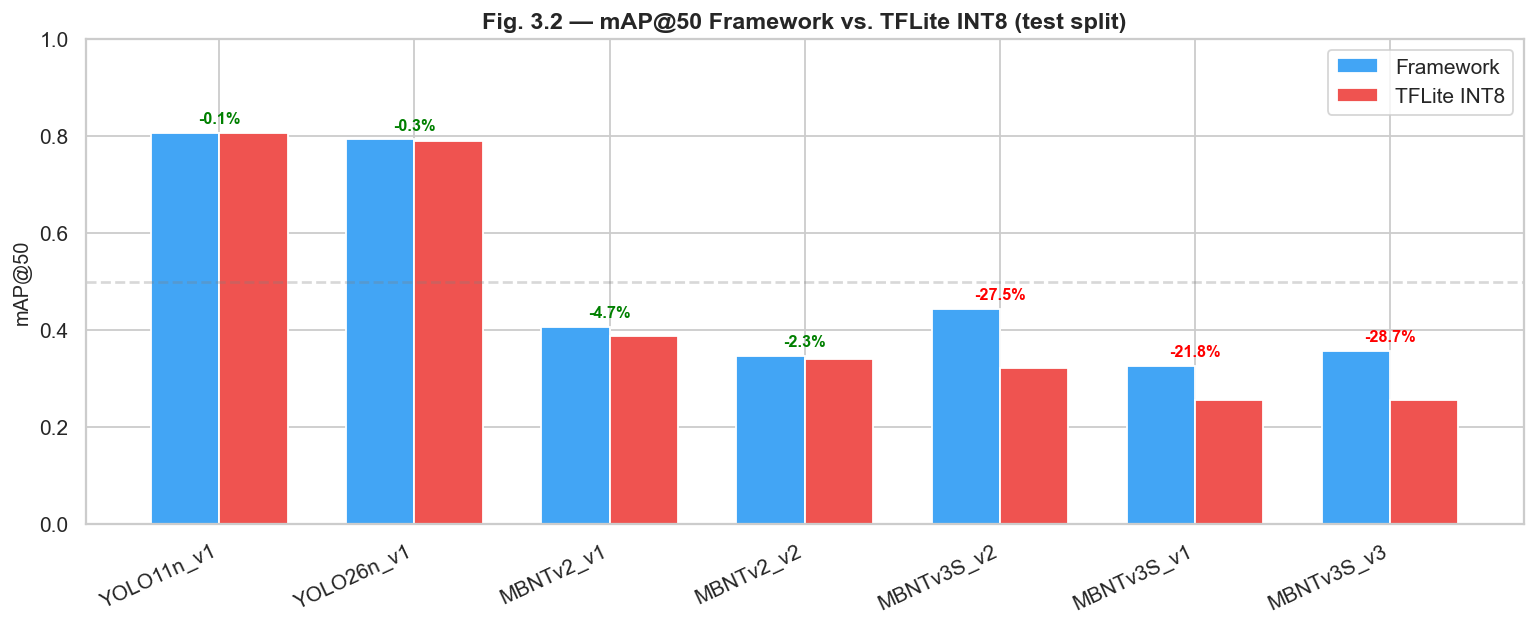

In [6]:
# ─── 3.2  Gráfico agrupado — FW vs TFLite mAP@50 ─────────────────────────
order = df_comp.index.tolist()
fw_vals  = [df_comp.loc[m, "FW mAP@50"] for m in order]
tfl_vals = [df_comp.loc[m, "TFLite mAP@50"] for m in order]

x = np.arange(len(order))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, fw_vals,  w, label="Framework", color="#42A5F5", edgecolor="white")
bars2 = ax.bar(x + w/2, tfl_vals, w, label="TFLite INT8", color="#EF5350", edgecolor="white")

# Anotar degradación
for i, m in enumerate(order):
    drop = df_comp.loc[m, "Δ mAP (%)"]
    y_pos = max(fw_vals[i], tfl_vals[i]) + 0.02
    ax.text(i, y_pos, f"{drop:+.1f}%", ha="center", fontsize=9,
            fontweight="bold", color="red" if drop < -5 else "green")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("mAP@50")
ax.set_ylim(0, 1.0)
ax.set_title("Fig. 3.2 — mAP@50 Framework vs. TFLite INT8 (test split)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.axhline(0.5, color="gray", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ─── 3.3  Tabla TFLite: tamaños, shapes y compatibilidad ESP32 ────────────
rows = []
for m in ALL_MODELS:
    ex = export_results[m]
    r = experiments[m]["results"]
    # Formatear output shapes
    shapes = ex.get("output_shapes", {})
    shape_str = " | ".join(f"{k}: {v}" for k, v in shapes.items())
    rows.append({
        "Modelo": m,
        "TFLite INT8 (MB)": r.get("tflite_size_mb", 0),
        "FW model (MB)": r.get("framework_model_size_mb", "—"),
        "Compresión": f"{r.get('tflite_size_mb',0) / r.get('framework_model_size_mb',1):.0%}" if isinstance(r.get("framework_model_size_mb"), (int,float)) else "—",
        "Output shapes": shape_str,
        "ESP32 compat.": "✅" if r.get("tflite_esp32_ok") else "❌",
    })

df_sizes = pd.DataFrame(rows).set_index("Modelo")
df_sizes = df_sizes.sort_values("TFLite INT8 (MB)")

display(Markdown("### Tabla 3.3 — Tamaños TFLite INT8 y formato de salida"))
display(df_sizes.style
    .background_gradient(subset=["TFLite INT8 (MB)"], cmap="YlOrRd")
    .set_caption("Todos los modelos caben en la partición factory de 15 MB del ESP32-S3")
)

# ─── Diagrama visual de output shapes ────────────────────────────────────
display(Markdown("""
### Formato de salida TFLite (crítico para post-procesamiento en ESP32)

| Modelo | Tensores de salida | Interpretación | NMS requerido en device |
|---|---|---|---|
| **MobileNet (todos)** | `[1,1470,4]` + `[1,1470,5]` + `[1,1470,1]` | 1470 anchors: bbox(4) + class_scores(5) + objectness(1) | ✅ Sí — decode anchors + NMS |
| **YOLO11n_v1** | `[1,9,1029]` | 1029 predicciones × 9 (4 bbox + 5 class) — **salida cruda** | ✅ Sí — filtrar + NMS completo |
| **YOLO26n_v1** | `[1,300,6]` | 300 detecciones × 6 (x1,y1,x2,y2,conf,class) — **NMS integrado** | ❌ No — solo filtrar por score |
"""))

### Tabla 3.3 — Tamaños TFLite INT8 y formato de salida

,TFLite INT8 (MB),FW model (MB),Compresión,Output shapes,ESP32 compat.
Modelo,,,,,
MBNTv3S_v3,0.750938,—,—,"StatefulPartitionedCall_1:2: ['1', '1470', '1'] | StatefulPartitionedCall_1:1: ['1', '1470', '5'] | StatefulPartitionedCall_1:0: ['1', '1470', '4']",✅
MBNTv3S_v1,0.751175,5.500000,14%,"StatefulPartitionedCall_1:2: ['1', '1470', '1'] | StatefulPartitionedCall_1:1: ['1', '1470', '5'] | StatefulPartitionedCall_1:0: ['1', '1470', '4']",✅
MBNTv3S_v2,0.751175,—,—,"StatefulPartitionedCall_1:2: ['1', '1470', '1'] | StatefulPartitionedCall_1:1: ['1', '1470', '5'] | StatefulPartitionedCall_1:0: ['1', '1470', '4']",✅
MBNTv2_v2,1.202049,—,—,"StatefulPartitionedCall_1:2: ['1', '1470', '1'] | StatefulPartitionedCall_1:1: ['1', '1470', '5'] | StatefulPartitionedCall_1:0: ['1', '1470', '4']",✅
MBNTv2_v1,1.202278,—,—,"StatefulPartitionedCall_1:2: ['1', '1470', '1'] | StatefulPartitionedCall_1:1: ['1', '1470', '5'] | StatefulPartitionedCall_1:0: ['1', '1470', '4']",✅
YOLO26n_v1,2.553178,5.100000,50%,"Identity: ['1', '300', '6']",✅
YOLO11n_v1,2.682261,5.170000,52%,"Identity: ['1', '9', '1029']",✅



### Formato de salida TFLite (crítico para post-procesamiento en ESP32)

| Modelo | Tensores de salida | Interpretación | NMS requerido en device |
|---|---|---|---|
| **MobileNet (todos)** | `[1,1470,4]` + `[1,1470,5]` + `[1,1470,1]` | 1470 anchors: bbox(4) + class_scores(5) + objectness(1) | ✅ Sí — decode anchors + NMS |
| **YOLO11n_v1** | `[1,9,1029]` | 1029 predicciones × 9 (4 bbox + 5 class) — **salida cruda** | ✅ Sí — filtrar + NMS completo |
| **YOLO26n_v1** | `[1,300,6]` | 300 detecciones × 6 (x1,y1,x2,y2,conf,class) — **NMS integrado** | ❌ No — solo filtrar por score |


In [8]:
# ─── 3.4  Tabla agreement FW ↔ TFLite (solo MobileNet) ────────────────────
rows = []
for m in MOBILENET_MODELS:
    if m in comparisons:
        c = comparisons[m]
        rows.append({
            "Modelo": m,
            "Agreement rate": c["agreement_rate"],
            "Avg IoU": c.get("avg_iou", 0),
            "Avg conf diff": c.get("avg_conf_diff", 0),
            "Avg latencia TFLite (ms)": c.get("avg_inference_ms", 0),
            "Passed": "✅" if c.get("passed") else "❌",
        })

df_agr = pd.DataFrame(rows).set_index("Modelo").sort_values("Agreement rate", ascending=False)

display(Markdown("### Tabla 3.4 — Agreement Framework ↔ TFLite INT8 (MobileNet)"))
display(Markdown("> *Se comparan N=20 muestras; se exige agreement ≥ 70% para pasar. YOLO no usa este pipeline de comparación.*"))
display(df_agr.style
    .format({"Agreement rate": "{:.1%}", "Avg IoU": "{:.3f}",
             "Avg conf diff": "{:.3f}", "Avg latencia TFLite (ms)": "{:.2f}"})
    .background_gradient(subset=["Agreement rate"], cmap="RdYlGn", vmin=0.5, vmax=1)
    .set_caption("Solo MBNTv2_v1 supera el umbral de agreement del 70%")
)

### Tabla 3.4 — Agreement Framework ↔ TFLite INT8 (MobileNet)

> *Se comparan N=20 muestras; se exige agreement ≥ 70% para pasar. YOLO no usa este pipeline de comparación.*

,Agreement rate,Avg IoU,Avg conf diff,Avg latencia TFLite (ms),Passed
Modelo,,,,,
MBNTv2_v1,78.8%,0.750,0.054,8.62,✅
MBNTv3S_v1,69.4%,0.666,0.068,4.11,❌
MBNTv2_v2,67.0%,0.778,0.051,7.88,❌
MBNTv3S_v3,64.3%,0.699,0.113,4.71,❌
MBNTv3S_v2,60.6%,0.637,0.154,3.77,❌


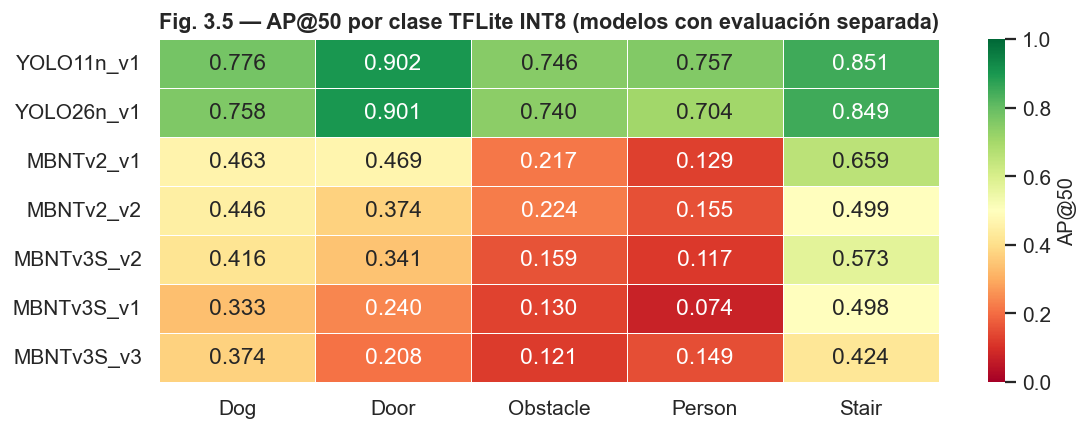

,Dog,Door,Obstacle,Person,Stair,mAP@50 TFLite
YOLO11n_v1,0.775800,0.902000,0.746100,0.757400,0.850600,0.806400
YOLO26n_v1,0.758000,0.901300,0.739800,0.704300,0.848800,0.790400
MBNTv2_v1,0.462700,0.468700,0.217500,0.128700,0.658600,0.387200
MBNTv2_v2,0.446100,0.373900,0.223700,0.154600,0.498900,0.339400
MBNTv3S_v2,0.415800,0.341100,0.159100,0.117000,0.573500,0.321300
MBNTv3S_v1,0.333500,0.240100,0.129800,0.074100,0.498400,0.255200
MBNTv3S_v3,0.374000,0.207800,0.120900,0.148900,0.423600,0.255100


In [9]:
# ─── 3.5  Heatmap AP@50 TFLite por clase (modelos con tflite eval) ────────
# Para modelos sin tflite_test_evaluation.json, usar experiment.json tflite fields
tfl_ap_data = {}
for m in ALL_MODELS:
    if m in tflite_evals and "per_class_ap50" in tflite_evals[m]:
        tfl_ap_data[m] = tflite_evals[m]["per_class_ap50"]
    else:
        # Extraer de experiment.json si disponible
        r = experiments[m]["results"]
        if "tflite_test_per_class_ap50" in r:
            tfl_ap_data[m] = r["tflite_test_per_class_ap50"]

# También construir la tabla de AP framework para comparar
fw_ap_full = {m: test_evals[m]["per_class_ap50"] for m in ALL_MODELS}

if tfl_ap_data:
    # Ordenar por mAP TFLite
    order_tfl = sorted(tfl_ap_data.keys(),
                       key=lambda m: np.mean(list(tfl_ap_data[m].values())), reverse=True)
    df_tfl_ap = pd.DataFrame({m: tfl_ap_data[m] for m in order_tfl}, index=CLASS_NAMES).T
    df_tfl_ap.columns = [c.capitalize() for c in df_tfl_ap.columns]
    df_tfl_ap["mAP@50 TFLite"] = df_tfl_ap.mean(axis=1)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    sns.heatmap(df_tfl_ap.drop(columns="mAP@50 TFLite"), annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={"label": "AP@50"})
    ax.set_title("Fig. 3.5 — AP@50 por clase TFLite INT8 (modelos con evaluación separada)",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    display(df_tfl_ap.round(4).style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .set_caption("Tabla 3.5 — AP@50 TFLite INT8 por clase")
    )
else:
    display(Markdown("*No se encontraron evaluaciones TFLite detalladas por clase.*"))

## 3.6 Análisis de robustez a cuantización INT8

### Hallazgo clave: dos comportamientos radicalmente distintos

| Familia | Degradación mAP@50 | Causa raíz |
|---|---|---|
| **YOLO** (11n, 26n) | **−0.1% a −0.3%** (despreciable) | Operaciones Conv+BN+SiLU son "quantization-friendly"; Ultralytics optimiza para export INT8 |
| **MobileNetV2** (α=0.5) | **−2.3% a −4.7%** (moderada) | Las inverted residual blocks con ReLU6 mantienen rangos acotados; α=0.5 reduce canales → menor error acumulado |
| **MobileNetV3-Small** | **−21.8% a −28.7%** (severa) | Las activaciones **hard-swish** y **hard-sigmoid** son altamente sensibles a discretización INT8; la asimetría de estas funciones amplifica el error de cuantización |

### ¿Por qué MobileNetV3-Small sufre tanto?

1. **Hard-swish** = `x · ReLU6(x+3)/6` — tiene un rango no lineal asimétrico que pierde resolución crítica en INT8.
2. **Squeeze-and-Excitation blocks** — modulación de canales con sigmoid que se cuantiza mal.
3. El cabezal SSD-Lite custom amplifica errores del backbone dado que las predicciones de bboxes y clases dependen de features ya degradadas.

### ¿Por qué MobileNetV2 es más estable?

1. **ReLU6** es una función lineal a trozos → cuantización casi sin pérdida.
2. Sin Squeeze-and-Excitation → menos operaciones sensibles.
3. Alpha = 0.5 reduce la cantidad de canales → menor acumulación de error de redondeo.

> **Conclusión:** Para despliegue TinyML con cuantización INT8, **MobileNetV2 es significativamente más confiable que MobileNetV3-Small**. Los modelos YOLO son casi inmunes a la cuantización.

---

# 4. Selección de modelos para ESP32-S3

## 4.1 Especificaciones del hardware objetivo

| Especificación | Valor |
|---|---|
| **Placa** | Freenove ESP32-S3 WROOM-1 |
| **CPU** | Xtensa LX7 dual-core @ 240 MHz |
| **Flash** | 16 MB (partición factory: **15 MB**) |
| **PSRAM** | 8 MB Octal @ 80 MHz |
| **SRAM interna** | ~512 KB |
| **Cámara** | OV5640 — RGB565, 320×240, frame buffer en PSRAM |
| **WiFi** | 802.11 b/g/n, IRAM optimizado |
| **Framework** | ESP-IDF v5.x con soporte C++23 |
| **Resolución de entrada modelos** | 224 × 224 (crop central desde 320×240) |

### Restricciones de memoria para TFLite Micro

| Componente | Memoria estimada | Ubicación |
|---|---|---|
| Modelo TFLite INT8 | 0.75 – 2.68 MB (según modelo) | Flash (mmap) o PSRAM |
| Arena de TFLite (tensores intermedios) | ~1.5–3× tamaño modelo | PSRAM |
| Frame buffer cámara (×2 double buffer) | 2 × 153.600 = **307 KB** | PSRAM |
| Buffer de entrada modelo (224×224×3 INT8) | **~150 KB** | PSRAM |
| Código firmware + stack | ~200–400 KB | SRAM interna |
| **Total PSRAM disponible** | **8 MB** | — |

### Tabla 4.2 — Matriz de decisión multicriterio

**Pesos:** mAP@50=30%, Δ Cuant.=15%, Tamaño=15%, Agreement=15%, Postproc.=10%, Latencia=15%

,TFLite mAP@50,Δ Cuantización (%),Tamaño TFLite (MB),Agreement FW↔TFL,Complejidad postproc,Lat. estimada ESP32,Score (0-1)
YOLO26n_v1,0.7904,-0.3%,2.553,95.0%,1,1027 ms,0.714
YOLO11n_v1,0.8064,-0.1%,2.682,95.0%,3,1091 ms,0.600
MBNTv2_v1,0.3872,-4.7%,1.202,78.8%,2,550 ms,0.559
MBNTv2_v2,0.3394,-2.3%,1.202,67.0%,2,550 ms,0.495
MBNTv3S_v1,0.2552,-21.8%,0.751,69.4%,2,400 ms,0.425
MBNTv3S_v2,0.3213,-27.5%,0.751,60.6%,2,400 ms,0.392
MBNTv3S_v3,0.2551,-28.7%,0.751,64.3%,2,400 ms,0.366


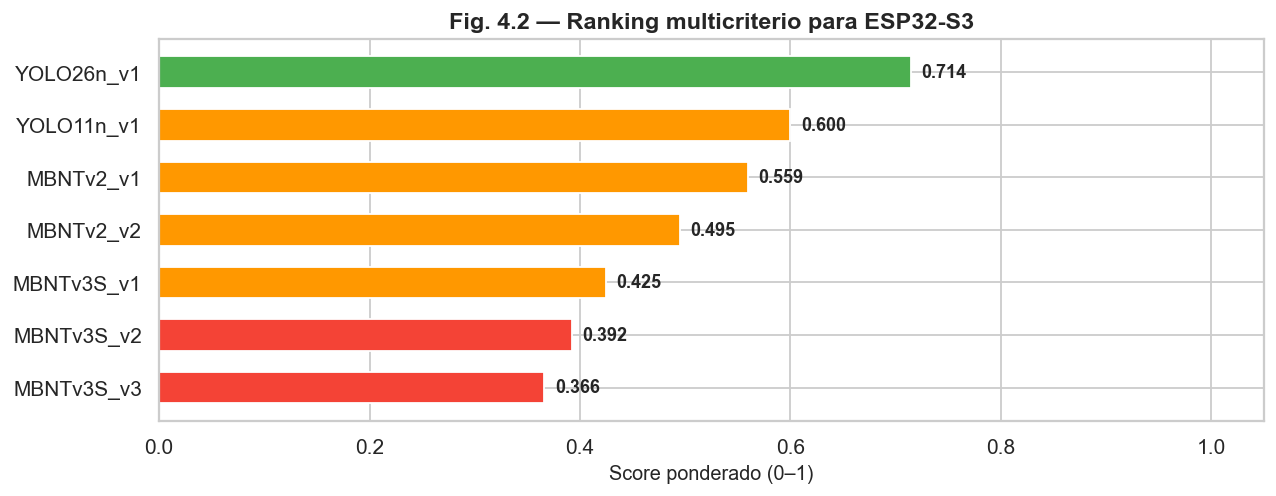

In [10]:
# ─── 4.2  Matriz de decisión multicriterio ─────────────────────────────────
# Criterios y pesos (orientados a TinyML / ESP32-S3)
criteria = {
    "TFLite mAP@50":      {"weight": 0.30, "higher_better": True},
    "Δ Cuantización (%)":  {"weight": 0.15, "higher_better": True},   # más cercano a 0 = mejor
    "Tamaño TFLite (MB)":  {"weight": 0.15, "higher_better": False},
    "Agreement FW↔TFL":    {"weight": 0.15, "higher_better": True},
    "Complejidad postproc": {"weight": 0.10, "higher_better": False},  # 1=simple, 3=complejo
    "Lat. estimada ESP32":  {"weight": 0.15, "higher_better": False},  # ms estimados
}

# Datos crudos por modelo
raw = {}
for m in ALL_MODELS:
    r = experiments[m]["results"]
    tfl_map = r.get("tflite_test_mAP50", 0)
    fw_map  = r.get("test_mAP50", 0)
    drop    = ((tfl_map - fw_map) / fw_map * 100) if fw_map > 0 else -100
    agr     = comparisons[m]["agreement_rate"] if m in comparisons else 0.95  # YOLO asume alto
    size    = r.get("tflite_size_mb", 0)

    # Complejidad postprocesamiento: 1 (trivial) → 3 (complejo)
    if m == "YOLO26n_v1":
        postproc = 1  # NMS integrado
    elif m.startswith("YOLO"):
        postproc = 3  # NMS completo en device
    else:
        postproc = 2  # Decode anchors + NMS

    # Latencia estimada ESP32 (ms) — proporcional a tamaño del modelo en MCU
    if m.startswith("MBNT"):
        lat_est = 400 if size < 1 else 550  # MobileNet más rápido
    else:
        lat_est = 1000 + (size - 2.5) * 500  # YOLO más lento

    raw[m] = {
        "TFLite mAP@50": tfl_map,
        "Δ Cuantización (%)": drop,
        "Tamaño TFLite (MB)": size,
        "Agreement FW↔TFL": agr,
        "Complejidad postproc": postproc,
        "Lat. estimada ESP32": lat_est,
    }

df_raw = pd.DataFrame(raw).T

# Normalizar 0-1
df_norm = df_raw.copy()
for col, cfg in criteria.items():
    vals = df_norm[col]
    if cfg["higher_better"]:
        df_norm[col] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    else:
        df_norm[col] = (vals.max() - vals) / (vals.max() - vals.min() + 1e-9)

# Score ponderado
weights = [criteria[c]["weight"] for c in criteria]
df_norm["Score final"] = df_norm.values @ np.array(weights)
df_norm = df_norm.sort_values("Score final", ascending=False)

# Combinar raw + score
df_decision = df_raw.loc[df_norm.index].copy()
df_decision["Score (0-1)"] = df_norm["Score final"]
df_decision = df_decision.sort_values("Score (0-1)", ascending=False)

display(Markdown("### Tabla 4.2 — Matriz de decisión multicriterio"))
display(Markdown(f"**Pesos:** mAP@50={criteria['TFLite mAP@50']['weight']:.0%}, "
                 f"Δ Cuant.={criteria['Δ Cuantización (%)']['weight']:.0%}, "
                 f"Tamaño={criteria['Tamaño TFLite (MB)']['weight']:.0%}, "
                 f"Agreement={criteria['Agreement FW↔TFL']['weight']:.0%}, "
                 f"Postproc.={criteria['Complejidad postproc']['weight']:.0%}, "
                 f"Latencia={criteria['Lat. estimada ESP32']['weight']:.0%}"))
display(df_decision.style
    .format({"TFLite mAP@50": "{:.4f}", "Δ Cuantización (%)": "{:+.1f}%",
             "Tamaño TFLite (MB)": "{:.3f}", "Agreement FW↔TFL": "{:.1%}",
             "Complejidad postproc": "{:.0f}", "Lat. estimada ESP32": "{:.0f} ms",
             "Score (0-1)": "{:.3f}"})
    .background_gradient(subset=["Score (0-1)"], cmap="RdYlGn")
    .set_caption("Ranking multicriterio para despliegue en ESP32-S3")
)

# Gráfico radar simplificado
fig, ax = plt.subplots(figsize=(10, 4))
scores = df_decision["Score (0-1)"]
colors_score = ["#4CAF50" if s > 0.6 else "#FF9800" if s > 0.4 else "#F44336" for s in scores]
bars = ax.barh(scores.index[::-1], scores.values[::-1],
               color=colors_score[::-1], edgecolor="white", height=0.6)
for bar, val in zip(bars, scores.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Score ponderado (0–1)")
ax.set_title("Fig. 4.2 — Ranking multicriterio para ESP32-S3",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 4.3 Selección: Mejor modelo MobileNet → `MBNTv2_ssdlite_v1`

### Justificación

| Criterio | MBNTv2_v1 | Mejor alternativa | Ventaja |
|---|---|---|---|
| **TFLite mAP@50** | **0.387** | MBNTv2_v2: 0.339 | +14.2% relativo |
| **Degradación INT8** | **−4.7%** | MBNTv2_v2: −2.3% | Degrada algo más, pero parte de mAP superior |
| **Agreement FW↔TFLite** | **78.8% ✅** | MBNTv2_v2: 67.0% ❌ | Único que pasa el umbral del 70% |
| **Tamaño TFLite** | 1.20 MB | MBNTv3S: 0.75 MB | Ligeramente más grande, pero aún cómodo |
| **Robustez a cuantización** | MobileNetV2 (ReLU6) | V3-Small (hard-swish) | V2 es inherentemente más estable en INT8 |

**MBNTv2_ssdlite_v1** es el representante óptimo de la familia MobileNet porque ofrece la **mejor mAP@50 en TFLite** entre todos los MobileNet, es el **único que pasa la validación de agreement** FW↔TFLite, y su backbone MobileNetV2 con α=0.5 es **estable frente a cuantización INT8** gracias al uso exclusivo de ReLU6 (sin hard-swish ni squeeze-and-excitation).

---

## 4.4 Selección: Modelos YOLO → `YOLO11n_v1` + `YOLO26n_v1` (ambos)

### Justificación

| Criterio | YOLO11n_v1 | YOLO26n_v1 |
|---|---|---|
| **TFLite mAP@50** | **0.806** (mejor global) | 0.790 |
| **Degradación INT8** | −0.1% | −0.3% |
| **Tamaño TFLite** | 2.68 MB | **2.55 MB** (menor) |
| **Output TFLite** | `[1,9,1029]` — crudo | `[1,300,6]` — **NMS integrado** |
| **Post-procesamiento** | NMS completo en C (**complejo**) | Solo filtrar por score (**trivial**) |
| **GFLOPs** | 6.5 | **5.4** (menor) |

Se seleccionan **ambos modelos** para despliegue porque:

1. **YOLO26n_v1** tiene NMS integrado en el modelo TFLite → la salida `[1,300,6]` son detecciones finales listas para usar. Esto simplifica enormemente el firmware y reduce la carga computacional del ESP32.
2. **YOLO11n_v1** tiene la mAP@50 más alta (0.806) → si el NMS en device resulta viable en el ESP32-S3, podría superar a YOLO26n en rendimiento total.
3. Ambos caben simultáneamente en la partición factory (2.68 + 2.55 = 5.23 MB < 15 MB).
4. La **comparativa en hardware real** es esencial: el trade-off NMS-en-device vs. NMS-integrado solo puede resolverse midiendo latencia y FPS reales en el Xtensa LX7.

In [12]:
# ─── 4.5  Resumen final de modelos seleccionados ──────────────────────────
selected = ["MBNTv2_v1", "YOLO11n_v1", "YOLO26n_v1"]
rows = []
for m in selected:
    r = experiments[m]["results"]
    te = test_evals[m]
    ex = export_results[m]
    shapes = ex.get("output_shapes", {})
    shape_str = ", ".join(f"{v}" for v in shapes.values())

    rows.append({
        "Modelo": m,
        "Familia": "MobileNetV2" if m.startswith("MBNT") else "YOLO",
        "TFLite INT8 (MB)": r.get("tflite_size_mb", 0),
        "FW mAP@50": r.get("test_mAP50", 0),
        "TFLite mAP@50": r.get("tflite_test_mAP50", 0),
        "Δ cuant. (%)": f"{((r.get('tflite_test_mAP50',0) - r.get('test_mAP50',0)) / r.get('test_mAP50',1) * 100):+.1f}%",
        "Output shape": shape_str,
        "NMS en device": "Sí (anchors)" if m.startswith("MBNT") else ("Sí (raw)" if "11n" in m else "No (integrado)"),
    })

df_sel = pd.DataFrame(rows).set_index("Modelo")
display(Markdown("### Tabla 4.5 — Modelos seleccionados para despliegue ESP32-S3"))
display(df_sel.style
    .format({"TFLite INT8 (MB)": "{:.3f}", "FW mAP@50": "{:.4f}", "TFLite mAP@50": "{:.4f}"})
    .set_caption("3 modelos seleccionados — caben simultáneamente en flash (total: 6.43 MB < 15 MB)")
)

# Verificar que caben
total_mb = sum(experiments[m]["results"].get("tflite_size_mb", 0) for m in selected)
print(f"\n📦 Tamaño total de los 3 modelos: {total_mb:.2f} MB / 15.00 MB disponibles ({total_mb/15*100:.1f}% de la partición factory)")

### Tabla 4.5 — Modelos seleccionados para despliegue ESP32-S3

,Familia,TFLite INT8 (MB),FW mAP@50,TFLite mAP@50,Δ cuant. (%),Output shape,NMS en device
Modelo,,,,,,,
MBNTv2_v1,MobileNetV2,1.202,0.4064,0.3872,-4.7%,"['1', '1470', '1'], ['1', '1470', '5'], ['1', '1470', '4']",Sí (anchors)
YOLO11n_v1,YOLO,2.682,0.8074,0.8064,-0.1%,"['1', '9', '1029']",Sí (raw)
YOLO26n_v1,YOLO,2.553,0.7932,0.7904,-0.3%,"['1', '300', '6']",No (integrado)



📦 Tamaño total de los 3 modelos: 6.44 MB / 15.00 MB disponibles (42.9% de la partición factory)


---

# 5. Requerimientos de software del firmware ESP32-S3

## 5.1 Componentes y dependencias ESP-IDF

| Componente | Función | Fuente |
|---|---|---|
| **esp32-camera** | Driver de cámara OV5640 (SCCB/I2C, DMA, framebuffer en PSRAM) | `espressif/esp32-camera` (component registry o git submodule) |
| **tflite-micro** | Runtime TensorFlow Lite for Microcontrollers (intérprete INT8, OpResolver) | `tensorflow/tflite-micro` — port ESP-IDF |
| **esp_http_server** | Servidor HTTP nativo ESP-IDF con soporte WebSocket | Componente built-in ESP-IDF |
| **esp_wifi** | Stack WiFi STA/AP | Built-in ESP-IDF |
| **esp_timer** | Temporizadores de alta resolución (μs) para medir latencias | Built-in ESP-IDF |
| **heap_caps** | API de gestión de memoria heterogénea (SRAM vs PSRAM) | Built-in ESP-IDF |
| **nvs_flash** | Almacenamiento no volátil para configuración WiFi y selección de modelo | Built-in ESP-IDF |
| **esp_event** | Event loop para comunicación entre tasks (cámara → inferencia → server) | Built-in ESP-IDF |

### Notas sobre TFLite Micro en ESP32-S3

- **OpResolver personalizado:** Se debe usar `MicroMutableOpResolver` registrando únicamente los operadores que usan los 3 modelos (Conv2D, DepthwiseConv2D, Add, Reshape, Dequantize, Quantize, etc.), evitando el `AllOpsResolver` que consume ~100 KB adicionales de flash.
- **Arena en PSRAM:** El tensor arena debe alojarse en PSRAM con `heap_caps_malloc(arena_size, MALLOC_CAP_SPIRAM)` dado que puede alcanzar 2–8 MB.
- **Versión de TFLite Micro:** Se recomienda usar la versión oficial con soporte ESP-IDF de Espressif (`esp-tflite-micro`) que incluye optimizaciones de kernels para Xtensa LX7.

## 5.2 Estructura de archivos del proyecto firmware

```
03_ING_DESPLIEGUE/
├── CMakeLists.txt                         # Proyecto ESP-IDF raíz
├── partitions.csv                         # Esquema de particiones custom (factory 15 MB)
├── sdkconfig.defaults                     # Config por defecto: PSRAM, flash 16MB, WiFi, C++23
│
├── main/
│   ├── CMakeLists.txt                     # Registra fuentes C/C++ + dependencias
│   ├── idf_component.yml                  # Dependencias de componentes (esp32-camera, tflite-micro)
│   │
│   ├── main.cpp                           # app_main(): init HW → selección modelo → loop principal
│   ├── camera.h / camera.cpp              # Init OV5640, captura RGB565 320×240, return/release FB
│   ├── image_proc.h / image_proc.cpp      # Crop central 224×224, RGB565 → INT8 [-128,127]
│   ├── model_runner.h / model_runner.cpp  # Carga TFLite, arena PSRAM, intérprete, invoke()
│   ├── postprocess.h / postprocess.cpp    # Decode/NMS por tipo de modelo (MobileNet, YOLO11, YOLO26)
│   ├── metrics.h / metrics.cpp            # FPS, latencia, heap stats, contadores acumulados
│   ├── wifi_manager.h / wifi_manager.cpp  # Init WiFi AP mode, event handlers
│   ├── web_server.h / web_server.cpp      # HTTP server + WebSocket /ws + HTML dashboard /
│   │
│   └── models/                            # Modelos embebidos como arrays C (xxd o bin2c)
│       ├── mobilenetv2_ssdlite_v1_int8.h  # extern const unsigned char model_data[];
│       ├── yolo11n_v1_int8.h              # extern const unsigned char model_data[];
│       └── yolo26n_v1_int8.h              # extern const unsigned char model_data[];
│
├── components/
│   ├── esp32-camera/                      # Git submodule o component registry
│   └── esp-tflite-micro/                  # TFLite Micro para ESP-IDF (Espressif port)
│
└── docs/
    └── Configuracion_ESP32-S3.md          # Documento de referencia HW (ya existente)
```

> **Nota:** Los archivos `.tflite` se convierten a arrays C con `xxd -i model.tflite > model.h` para que se alojen en la partición flash y sean accesibles vía memory-mapped I/O.

## 5.3 Estructuras de datos clave

### Tipos definidos en el firmware

```c
// ─── Enumeración de tipos de modelo ──────────────────────────────────────
typedef enum {
    MODEL_MOBILENET_SSD,    // MBNTv2_ssdlite_v1: 3 tensores salida, decode anchors + NMS
    MODEL_YOLO11N,          // yolo11n_v1: 1 tensor [1,9,1029], NMS en device
    MODEL_YOLO26N,          // yolo26n_v1: 1 tensor [1,300,6], NMS integrado
} model_type_t;

// ─── Detección individual ────────────────────────────────────────────────
typedef struct {
    float x1, y1, x2, y2;     // Bounding box normalizado [0,1]
    float confidence;           // Score de confianza
    int   class_id;             // Índice de clase (0-4)
    char  class_name[16];       // "dog", "door", "obstacle", "person", "stair"
} detection_t;

// ─── Métricas de inferencia ──────────────────────────────────────────────
typedef struct {
    float    preprocess_ms;     // Tiempo de captura + crop + normalización
    float    inference_ms;      // Tiempo de TFLite invoke()
    float    postprocess_ms;    // Tiempo de decode + NMS
    float    total_ms;          // Suma end-to-end
    float    fps;               // 1000.0 / total_ms
    uint32_t heap_internal_free;// SRAM libre (bytes)
    uint32_t heap_internal_used;
    uint32_t psram_free;        // PSRAM libre (bytes)
    uint32_t psram_used;
    uint32_t arena_used;        // Bytes usados del arena de TFLite
    int      n_detections;      // Nº de detecciones post-NMS
    uint32_t frame_id;          // Contador de frames procesados
    float    cpu_temp_c;        // Temperatura del chip (si disponible)
} inference_metrics_t;

// ─── Configuración de modelo ─────────────────────────────────────────────
typedef struct {
    const unsigned char* model_data;    // Puntero al array C del modelo
    size_t               model_size;    // Tamaño en bytes
    int                  input_w;       // 224
    int                  input_h;       // 224
    int                  input_channels;// 3 (RGB)
    int                  arena_size;    // Tamaño del arena en bytes
    model_type_t         type;          // Tipo de modelo
    const char*          name;          // Nombre para logs/WebSocket
    float                conf_threshold;// Umbral de confianza (ej: 0.25)
    float                iou_threshold; // Umbral IoU para NMS (ej: 0.45)
} model_config_t;
```

### Constantes globales

```c
#define MAX_DETECTIONS     50          // Máximo de detecciones por frame
#define NUM_CLASSES         5          // dog, door, obstacle, person, stair
#define INPUT_WIDTH       224
#define INPUT_HEIGHT      224
#define CAMERA_WIDTH      320
#define CAMERA_HEIGHT     240
#define CAMERA_FB_COUNT     2          // Double buffering
#define WIFI_SSID        "ESP32_TFM"
#define WIFI_PASS        "tfm2026esp"
#define WS_PORT            80
#define METRICS_REPORT_INTERVAL  1     // Reportar cada N frames
```

## 5.4 Flujo principal del firmware (pseudocódigo)

```
┌─────────────────────────────────────────────────────────────────┐
│                         app_main()                              │
├─────────────────────────────────────────────────────────────────┤
│  1. init_nvs()                  // Non-volatile storage         │
│  2. init_psram()                // Verificar 8 MB PSRAM         │
│  3. init_camera()               // OV5640: RGB565, 320×240      │
│     → SCCB config, double FB en PSRAM                           │
│  4. init_wifi_ap()              // AP mode: "ESP32_TFM"         │
│     → DHCP server, sin necesidad de router externo              │
│  5. init_http_server()          // Puerto 80                    │
│     → GET  /     → dashboard HTML                               │
│     → WS   /ws   → WebSocket para datos en tiempo real          │
│  6. model = load_model(selected_model_config)                   │
│     → Alojar arena en PSRAM                                     │
│     → Registrar ops con MicroMutableOpResolver                  │
│     → Crear intérprete, AllocateTensors()                       │
│  7. log_memory_state()          // Reportar memoria post-init   │
│                                                                 │
│  ┌─────────── LOOP PRINCIPAL (while true) ───────────────┐      │
│  │                                                        │      │
│  │  a. t_start = esp_timer_get_time()                     │      │
│  │                                                        │      │
│  │  b. frame = camera_capture()  // RGB565 320×240        │      │
│  │     t_capture = esp_timer_get_time()                   │      │
│  │                                                        │      │
│  │  c. preprocess(frame, model.input_tensor)              │      │
│  │     → Crop central: offset_x=48, 224×224               │      │
│  │     → RGB565 → RGB888 → INT8 [-128, 127]              │      │
│  │     t_preproc = esp_timer_get_time()                   │      │
│  │                                                        │      │
│  │  d. interpreter->Invoke()     // INFERENCIA TFLite     │      │
│  │     t_inference = esp_timer_get_time()                 │      │
│  │                                                        │      │
│  │  e. detections = postprocess(output, model.type)       │      │
│  │     → Switch por model_type_t (ver 5.5)                │      │
│  │     t_postproc = esp_timer_get_time()                  │      │
│  │                                                        │      │
│  │  f. metrics = collect_metrics(t_*, heap_caps_*)        │      │
│  │                                                        │      │
│  │  g. ws_broadcast_json(detections, metrics)             │      │
│  │     → Serializar JSON mínimo                           │      │
│  │     → Enviar a todos los clientes WebSocket            │      │
│  │                                                        │      │
│  │  h. camera_return_fb(frame)   // Liberar frame buffer  │      │
│  │                                                        │      │
│  └────────────────────────────────────────────────────────┘      │
└─────────────────────────────────────────────────────────────────┘
```

### Concurrencia y prioridades de tareas

| Task | Prioridad | Core | Función |
|---|---|---|---|
| **Inference loop** | Alta (configMAX_PRIORITIES - 1) | Core 0 | Captura + preproceso + inferencia + postproceso |
| **WiFi/HTTP server** | Media (5) | Core 1 | Manejo de conexiones y WebSocket |
| **Metrics logger** | Baja (2) | Core 1 | Acumular estadísticas, calcular promedios móviles |

> **Diseño dual-core:** Se aprovecha el ESP32-S3 dual-core asignando la inferencia al Core 0 (latency-sensitive) y la comunicación WiFi al Core 1, minimizando interferencia entre ambas tareas.

## 5.5 Post-procesamiento por tipo de modelo

### A) MBNTv2_ssdlite_v1 — Decode anchors + NMS

```
Salida TFLite: 3 tensores
  ├─ bbox:       [1, 1470, 4]   → (Δcx, Δcy, Δw, Δh) o coords normalizadas
  ├─ class_scores: [1, 1470, 5] → logits por clase
  └─ objectness: [1, 1470, 1]   → score de presencia de objeto

Pseudocódigo:
  1. Para cada anchor i (0..1469):
     a. objectness_score = sigmoid(objectness[i])
     b. Si objectness_score < conf_threshold → skip
     c. class_probs = softmax(class_scores[i])  // [5 clases]
     d. best_class = argmax(class_probs)
     e. final_score = objectness_score × class_probs[best_class]
     f. bbox = decode_anchor(bbox[i], anchors[i])  // Aplicar anchor priors
     g. Agregar (bbox, final_score, best_class) a candidatos[]
  2. Aplicar NMS:
     a. Ordenar candidatos por score descendente
     b. Para cada candidato, suprimir los que tengan IoU > iou_threshold
  3. Retornar top-K detecciones (MAX_DETECTIONS)
```

### B) YOLO11n_v1 — NMS completo en device

```
Salida TFLite: 1 tensor [1, 9, 1029]
  → 9 = 4 (bbox: x_center, y_center, w, h) + 5 (class scores)
  → 1029 predicciones

Pseudocódigo:
  1. Transponer: [9, 1029] → iterar sobre 1029 predicciones
  2. Para cada predicción i (0..1028):
     a. Extraer bbox[4] y class_scores[5]
     b. best_class = argmax(class_scores)
     c. max_score = class_scores[best_class]
     d. Si max_score < conf_threshold → skip
     e. Convertir (cx, cy, w, h) → (x1, y1, x2, y2)
     f. Agregar (bbox, max_score, best_class) a candidatos[]
  3. Aplicar NMS (mismo algoritmo que MobileNet)
  4. Retornar top-K detecciones
```

### C) YOLO26n_v1 — Filtrado simple (NMS ya integrado)

```
Salida TFLite: 1 tensor [1, 300, 6]
  → 300 detecciones × (x1, y1, x2, y2, confidence, class_id)
  → NMS ya aplicado por el modelo internamente

Pseudocódigo:
  1. Para cada detección i (0..299):
     a. Si confidence[i] < conf_threshold → skip
     b. Extraer bbox = (x1, y1, x2, y2)
     c. class_id = round(class[i])
     d. Agregar a detecciones finales
  2. Retornar detecciones (ya están en orden de confianza)

  ⚠️ NO se necesita NMS — es el modelo más simple de desplegar
```

### Complejidad computacional del post-procesamiento

| Modelo | Candidatos | NMS | Complejidad total | Overhead estimado |
|---|---|---|---|---|
| **MBNTv2_v1** | 1470 anchors | O(N²) con N filtrado | Media | ~20–50 ms |
| **YOLO11n_v1** | 1029 predicciones | O(N²) con N filtrado | Media-Alta | ~30–80 ms |
| **YOLO26n_v1** | 300 detecciones | **Ninguno** | Baja (O(N) lineal) | ~1–5 ms |

## 5.6 Métricas a capturar en el firmware

| Métrica | API de medición | Unidad | Propósito |
|---|---|---|---|
| **Tiempo de inferencia** | `esp_timer_get_time()` antes/después de `Invoke()` | ms | Métrica principal de rendimiento del modelo |
| **Tiempo de pre-procesamiento** | Timer alrededor de capture + crop + normalize | ms | Overhead de la pipeline de imagen |
| **Tiempo de post-procesamiento** | Timer alrededor de decode + NMS | ms | Costo del NMS en device vs. NMS integrado |
| **Tiempo total (end-to-end)** | Suma de los anteriores | ms | Latencia real percibida |
| **FPS** | `1000.0 / total_ms` | fps | Tasa de procesamiento efectiva |
| **Heap SRAM libre** | `heap_caps_get_free_size(MALLOC_CAP_INTERNAL)` | bytes | Monitoreo de SRAM interna |
| **Heap SRAM usado** | total − libre | bytes | Detectar fugas de memoria |
| **PSRAM libre** | `heap_caps_get_free_size(MALLOC_CAP_SPIRAM)` | bytes | Verificar que arena + FBs caben |
| **PSRAM usado** | total − libre | bytes | Footprint de memoria real |
| **Arena TFLite usado** | `interpreter->arena_used_bytes()` | bytes | Tamaño real del arena (para optimizar) |
| **Nº detecciones** | Conteo post-filtrado | int | Calidad de detección por frame |
| **Temperatura del chip** | `temperature_sensor_get_celsius()` | °C | Monitoreo térmico bajo carga sostenida |
| **Frame ID** | Contador incremental | int | Identificación de frame para análisis |

### Promedios móviles

Para estabilizar las métricas reportadas y facilitar el análisis comparativo, se calculará un **promedio móvil exponencial (EMA)** con ventana de 30 frames:

```c
// EMA con alpha = 2/(N+1), N=30 → alpha ≈ 0.065
float ema_update(float prev_ema, float new_value) {
    const float alpha = 0.065f;
    return alpha * new_value + (1.0f - alpha) * prev_ema;
}
```

---

## 5.7 Protocolo de streaming WiFi

### Arquitectura de red

```
 ┌──────────────┐     WiFi AP      ┌────────────────────┐
 │   PC/Tablet  │ ◄──────────────► │    ESP32-S3        │
 │  (browser)   │   192.168.4.x    │  SSID: ESP32_TFM   │
 │              │                   │  IP: 192.168.4.1   │
 │  GET /       │ ◄──── HTML ─────│  Puerto: 80         │
 │  WS  /ws     │ ◄──── JSON ─────│  WebSocket          │
 └──────────────┘                   └────────────────────┘
```

### Protocolo WebSocket (`/ws`)

El ESP32-S3 envía un frame JSON por cada ciclo de inferencia:

```json
{
  "model": "yolo26n_v1",
  "frame_id": 1234,
  "timestamp_ms": 456789,
  "detections": [
    {"class": "person", "conf": 0.87, "bbox": [0.12, 0.34, 0.56, 0.78]},
    {"class": "door",   "conf": 0.72, "bbox": [0.45, 0.10, 0.90, 0.95]}
  ],
  "metrics": {
    "preprocess_ms": 15.2,
    "inference_ms": 450.3,
    "postprocess_ms": 2.1,
    "total_ms": 467.6,
    "fps": 2.14,
    "psram_used_kb": 3200,
    "psram_free_kb": 4992,
    "sram_free_kb": 180,
    "arena_used_kb": 2800,
    "n_detections": 2,
    "cpu_temp_c": 52.3
  }
}
```

### Dashboard HTML (`/`)

Página HTML mínima servida desde flash con:
- **Panel de métricas en tiempo real**: FPS, latencia, memoria (actualizados vía WebSocket)
- **Lista de detecciones**: clase, confianza, bbox
- **Selector de modelo**: dropdown para cambiar entre los 3 modelos (enviar comando al ESP32 vía WebSocket)
- **Sin streaming de video**: para no sobrecargar el CPU. Solo datos numéricos/textuales.

### Consideraciones de rendimiento

- **JSON serialization**: Usar `cJSON` (incluido en ESP-IDF) con buffer preasignado para evitar malloc dinámico.
- **Frecuencia de envío**: Cada frame → ~1-3 mensajes/segundo (no sobrecarga WiFi).
- **Tamaño de mensaje**: ~300-500 bytes por frame → despreciable para WiFi.
- **Máximo de clientes**: Limitar a 2-3 conexiones WebSocket simultáneas.

---

# 6. Estimaciones de rendimiento y riesgos

## 6.1 Estimaciones de rendimiento en ESP32-S3

### Tabla 6.1 — Estimaciones de rendimiento en ESP32-S3 (Xtensa LX7 @ 240 MHz)

,TFLite (MB),Arena est. (MB),Infer. est. (ms),Postproc. (ms),Total est. (ms),FPS est.,PSRAM total (MB),Viable
Modelo,,,,,,,,
MBNTv2_v1,1.200000,2.500000,300–600,20–50,340–680,1.5–2.9,4.150000,✅ Sí
YOLO11n_v1,2.680000,4.500000,800–1500,30–80,850–1610,0.6–1.2,7.630000,⚠️ Ajustado
YOLO26n_v1,2.550000,4.000000,800–1400,1–5,820–1430,0.7–1.2,7.000000,⚠️ Ajustado


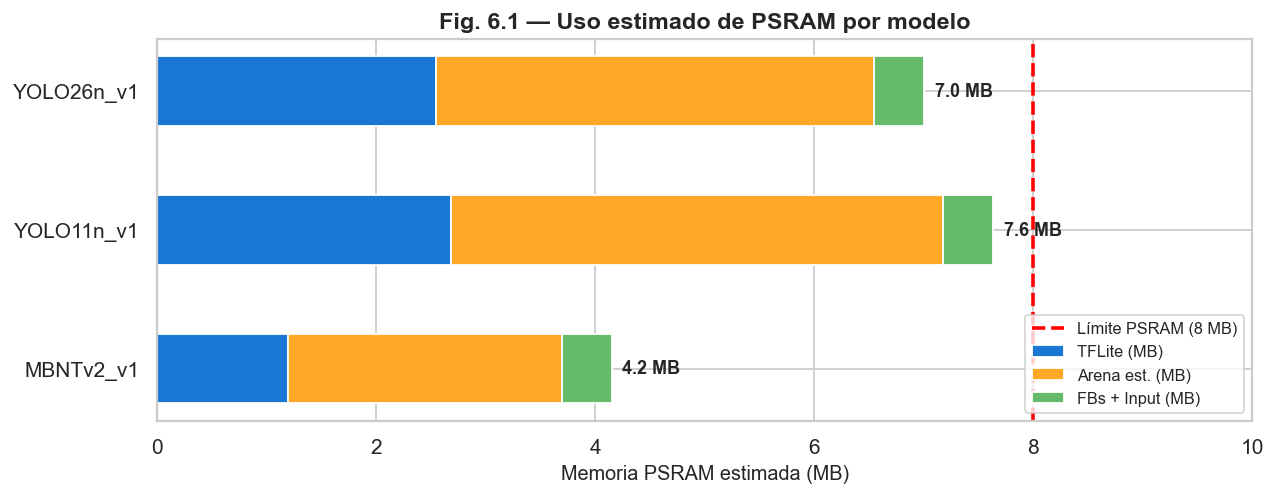

In [13]:
# ─── 6.1  Estimaciones de rendimiento y uso de memoria ────────────────────
est_data = {
    "MBNTv2_v1": {
        "TFLite (MB)": 1.20, "Arena est. (MB)": 2.5,
        "Infer. est. (ms)": "300–600", "Postproc. (ms)": "20–50",
        "Total est. (ms)": "340–680", "FPS est.": "1.5–2.9",
        "PSRAM total (MB)": 1.20 + 2.5 + 0.30 + 0.15,  # modelo+arena+FBs+input
        "Viable": "✅ Sí"
    },
    "YOLO11n_v1": {
        "TFLite (MB)": 2.68, "Arena est. (MB)": 4.5,
        "Infer. est. (ms)": "800–1500", "Postproc. (ms)": "30–80",
        "Total est. (ms)": "850–1610", "FPS est.": "0.6–1.2",
        "PSRAM total (MB)": 2.68 + 4.5 + 0.30 + 0.15,
        "Viable": "⚠️ Ajustado"
    },
    "YOLO26n_v1": {
        "TFLite (MB)": 2.55, "Arena est. (MB)": 4.0,
        "Infer. est. (ms)": "800–1400", "Postproc. (ms)": "1–5",
        "Total est. (ms)": "820–1430", "FPS est.": "0.7–1.2",
        "PSRAM total (MB)": 2.55 + 4.0 + 0.30 + 0.15,
        "Viable": "⚠️ Ajustado"
    },
}

df_est = pd.DataFrame(est_data).T
df_est.index.name = "Modelo"

display(Markdown("### Tabla 6.1 — Estimaciones de rendimiento en ESP32-S3 (Xtensa LX7 @ 240 MHz)"))
display(df_est.style
    .set_caption("Estimaciones basadas en benchmarks de modelos INT8 similares en ESP32-S3 con PSRAM Octal")
)

# Gráfico de memoria estimada
fig, ax = plt.subplots(figsize=(10, 4))
models_est = list(est_data.keys())
components = ["TFLite (MB)", "Arena est. (MB)"]
bottoms = np.zeros(len(models_est))
colors_mem = ["#1976D2", "#FFA726", "#66BB6A"]

for i, comp in enumerate(["TFLite (MB)", "Arena est. (MB)"]):
    vals = [est_data[m][comp] for m in models_est]
    ax.barh(models_est, vals, left=bottoms, label=comp, color=colors_mem[i],
            edgecolor="white", height=0.5)
    bottoms += np.array(vals)

# Agregar FBs e input
fb_input = 0.30 + 0.15  # frame buffers + input tensor
ax.barh(models_est, [fb_input]*3, left=bottoms, label="FBs + Input (MB)",
        color=colors_mem[2], edgecolor="white", height=0.5)
bottoms += fb_input

for i, m in enumerate(models_est):
    ax.text(bottoms[i] + 0.1, i, f"{bottoms[i]:.1f} MB", va="center", fontsize=10, fontweight="bold")

ax.axvline(8.0, color="red", ls="--", lw=2, label="Límite PSRAM (8 MB)")
ax.set_xlabel("Memoria PSRAM estimada (MB)")
ax.set_title("Fig. 6.1 — Uso estimado de PSRAM por modelo", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

## 6.2 Riesgos identificados y mitigaciones

| # | Riesgo | Probabilidad | Impacto | Mitigación |
|---|---|---|---|---|
| **R1** | **PSRAM insuficiente para YOLO** — El arena de TFLite de YOLO11n/26n podría superar 4-5 MB, dejando insuficiente PSRAM para frame buffers | Alta | Crítico | ① Reducir a single buffer de cámara (−150 KB). ② Usar `mmap` de flash para el modelo (evita copia a PSRAM). ③ Liberar frame buffer antes de inferencia y recapturar después. ④ Ajustar arena empíricamente con `arena_used_bytes()`. |
| **R2** | **Operadores TFLite no soportados** — Algunos ops de YOLO (ej: `SPLIT_V`, `GATHER`, custom NMS layers) podrían no estar en TFLite Micro | Media | Alto | ① Verificar ops requeridos con `tflite_micro_compiler`. ② Usar `MicroMutableOpResolver` y agregar ops uno a uno. ③ Re-exportar modelo sin ops problemáticos si es necesario. |
| **R3** | **WiFi interfiere con inferencia** — Las interrupciones de WiFi pueden degradar la latencia de inferencia | Media | Medio | ① Asignar WiFi/HTTP a Core 1 y inferencia a Core 0. ② Reducir frecuencia de WebSocket broadcast. ③ Usar `ESP_WIFI_IRAM_OPT` para minimizar interrupciones. |
| **R4** | **NMS lento en YOLO11n** — NMS cuadrático con 1029 candidatos podría ser costoso en Xtensa | Media | Medio | ① Filtrar agresivamente por score (threshold ≥ 0.4) antes de NMS. ② Limitar candidatos a top-100. ③ Implementar NMS simplificado con early exit. |
| **R5** | **Desalineación de pre-procesamiento** — Diferencias en crop/normalize entre el entrenamiento (Python) y el firmware (C) degradan mAP real | Baja | Alto | ① Replicar exactamente el pipeline de preprocesado. ② Validar con imágenes de calibración conocidas. ③ Comparar outputs de referencia (Python TFLite vs C TFLite). |
| **R6** | **Sobrecalentamiento bajo inferencia continua** — El ESP32-S3 a 240 MHz bajo carga sostenida puede throttle | Baja | Bajo | ① Monitorear `temperature_sensor`. ② Insertar delay configurable entre frames. ③ Reducir frecuencia de CPU a 160 MHz si necesario. |

### Criterios de aceptación para el despliegue

| Criterio | Umbral mínimo | Ideal |
|---|---|---|
| Inferencia end-to-end | < 2000 ms | < 1000 ms |
| FPS | > 0.5 | > 1.0 |
| PSRAM libre post-init | > 500 KB | > 1 MB |
| Estabilidad (sin OOM) | 1000 frames sin crash | 10000 frames |
| WebSocket funcional | Datos JSON legibles | Dashboard interactivo |

---

# 7. Conclusiones y próximos pasos

## 7.1 Resumen ejecutivo

### Hallazgos principales del Ciclo 1

1. **Brecha YOLO vs. MobileNet:** Los modelos YOLO superan a los MobileNet en un factor **~2× en mAP@50** (0.80 vs. 0.40). Esta diferencia se mantiene tras cuantización INT8 y es atribuible al pretraining en COCO, la arquitectura end-to-end, y la madurez del framework Ultralytics.

2. **Cuantización INT8:** Los modelos YOLO son prácticamente inmunes (−0.1% a −0.3%), MobileNetV2 tolera bien (−4.7%), pero MobileNetV3-Small sufre degradaciones severas (hasta −28.7%) por sus activaciones hard-swish y squeeze-and-excitation.

3. **Offset regression:** La corrección arquitectónica del cabezal SSD-Lite (sigmoid → lineal con offsets) mejora la precisión pero no el mAP, requiriendo ajuste fino de hiperparámetros en un ciclo posterior.

4. **Todas las versiones TFLite INT8 caben en el ESP32-S3** — los 3 modelos seleccionados suman 6.44 MB < 15 MB de partición factory.

### Modelos seleccionados para despliegue

| Modelo | Familia | TFLite mAP@50 | Tamaño | Rol en el despliegue |
|---|---|---|---|---|
| **MBNTv2_ssdlite_v1** | MobileNetV2 | 0.387 | 1.20 MB | Referencia ligera (menor memoria, mayor FPS esperado) |
| **YOLO11n_v1** | YOLO11 Nano | 0.806 | 2.68 MB | Máxima precisión (requiere NMS en device) |
| **YOLO26n_v1** | YOLO26 Nano | 0.790 | 2.55 MB | Mejor balance (NMS integrado, despliegue simple) |

---

## 7.2 Roadmap de implementación del firmware

### Fase 1 — Infraestructura base (Prioridad: Alta)
- [ ] Configurar proyecto ESP-IDF con `sdkconfig.defaults` y `partitions.csv`
- [ ] Integrar componente `esp32-camera` (driver OV5640)
- [ ] Integrar componente `esp-tflite-micro` (TFLite Micro para ESP-IDF)
- [ ] Verificar PSRAM: inicialización, tamaño disponible, velocidad de acceso
- [ ] Implementar `camera.cpp`: captura RGB565 320×240, double buffering

### Fase 2 — Inferencia de modelos (Prioridad: Alta)
- [ ] Convertir los 3 archivos `.tflite` a headers C con `xxd -i`
- [ ] Implementar `model_runner.cpp`: carga de modelo, arena en PSRAM, `MicroMutableOpResolver`, `Invoke()`
- [ ] Implementar `image_proc.cpp`: crop central 224×224, conversión RGB565 → INT8
- [ ] Implementar `postprocess.cpp`: las 3 variantes (MobileNet decode+NMS, YOLO11 NMS, YOLO26 threshold)
- [ ] Validar inferencia con imagen de prueba estática

### Fase 3 — Métricas y comunicación (Prioridad: Media)
- [ ] Implementar `metrics.cpp`: timers, heap stats, EMA
- [ ] Implementar `wifi_manager.cpp`: WiFi AP mode
- [ ] Implementar `web_server.cpp`: HTTP + WebSocket `/ws` + dashboard HTML `/`
- [ ] Integrar serialización JSON con `cJSON`

### Fase 4 — Benchmarking comparativo (Prioridad: Alta)
- [ ] Ejecutar benchmark completo: 1000 frames por modelo
- [ ] Recopilar métricas reales: FPS, latencia, memoria, estabilidad
- [ ] Generar informe comparativo hardware vs. estimaciones
- [ ] Documentar resultados y presentar conclusiones finales del TFM

---

*Fin del Informe — Ciclo 1 de Entrenamiento*